In [2]:
%cd ../../

/Users/macos/Uni/1st_year/period_2/IntroML/homework


In [75]:
from typing import Tuple
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
from sklearn import linear_model
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

In [4]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

## Task a

In [5]:
path_train = "E1/data/train_syn.csv"
path_val = "E1/data/valid_syn.csv"
path_test = "E1/data/test_syn.csv"

df_train, df_val, df_test = pd.read_csv(path_train), pd.read_csv(path_val), pd.read_csv(path_test)

In [6]:
df_train.head()

,x,y
0,2.488836,6.151458
1,2.622452,6.089627
2,-1.283163,4.478079
3,1.982686,3.913185
4,0.850473,2.769593


In [48]:
df_trainval = pd.concat([df_train, df_val])

### Add x^p

In [7]:
for p in range(9):
    df_train[f"x{p}"] = np.power(df_train['x'], p)
    df_val[f"x{p}"] = np.power(df_val['x'], p)
    df_test[f"x{p}"] = np.power(df_test['x'], p)

In [8]:
def rss(ytarget: np.ndarray, ypred: np.ndarray):
    return np.sum(np.power(ytarget - ypred, 2))

def get_Xy(df: pd.DataFrame, p: int) -> Tuple[np.ndarray, np.ndarray]:
    xs = [f'x{p_}' for p_ in range(p+1)]
    X = df[xs].to_numpy()
    if len(X.shape) == 1:
        X = X.reshape(-1, 1)
    y = df['y'].to_numpy().reshape(-1, 1)

    return X, y


In [28]:
results = []
models = {}

for p in range(9):
    result = {'degree': p}

    ols = linear_model.LinearRegression()

    # Calculate Train, Val, Test RSS error
    Xtrain, ytrain = get_Xy(df_train, p)
    Xval, yval = get_Xy(df_val, p)
    Xtest, ytest = get_Xy(df_test, p)

    ols.fit(Xtrain, ytrain)

    ypred_train = ols.predict(Xtrain)
    ypred_val = ols.predict(Xval)
    ypred_test = ols.predict(Xtest)

    rss_train = rss(ytrain, ypred_train)
    rss_val = rss(yval, ypred_val)
    rss_test = rss(ytest, ypred_test)

    result["train"] = rss_train
    result["val"] = rss_val
    result["test"] = rss_test

    # Calculate TestTRVA error
    X, y = get_Xy(df_trainval, p)
    ols.fit(X, y)
    models[p] = deepcopy(ols)

    ypred_test = ols.predict(Xtest)
    rss_test = rss(ytest, ypred_test)
    result["test_trva"] = rss_test

    # Calculate CV
    mse = []
    for idx_train, idx_val in KFold(n_splits=5).split(df_trainval):
        Xtrain, ytrain = get_Xy(df_trainval.iloc[idx_train], p)
        Xval, yval = get_Xy(df_trainval.iloc[idx_val], p)

        ols.fit(Xtrain, ytrain)

        ypred_val = ols.predict(Xval)
        mse_i = mean_squared_error(yval, ypred_val)
        mse.append(mse_i)

    mse_final = sum(mse) / len(mse)
    result["cv"] = mse_final

    # Append result
    results.append(result)

In [10]:
pd.DataFrame.from_records(results)

,degree,train,val,test,test_trva,cv
0,0,45.122613,66.593441,1.171646e+04,11263.216511,6.175722
1,1,40.885351,71.278436,8.876307e+03,9934.942593,7.048031
2,2,2.185859,2.937319,2.458467e+02,214.016106,0.307891
3,3,2.168190,2.834474,2.900799e+02,275.110577,0.365361
4,4,1.187955,6.247259,9.690780e+02,223.992887,0.537302
5,5,0.965322,5.734800,4.894836e+03,1039.088997,0.462643
6,6,0.075741,34.167870,2.132971e+05,881.470788,0.593473
7,7,0.049994,68.629927,1.261988e+06,271.718641,0.658296
8,8,0.020825,4016.517804,1.542669e+08,11223.554150,2.037385


## Task b

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a 

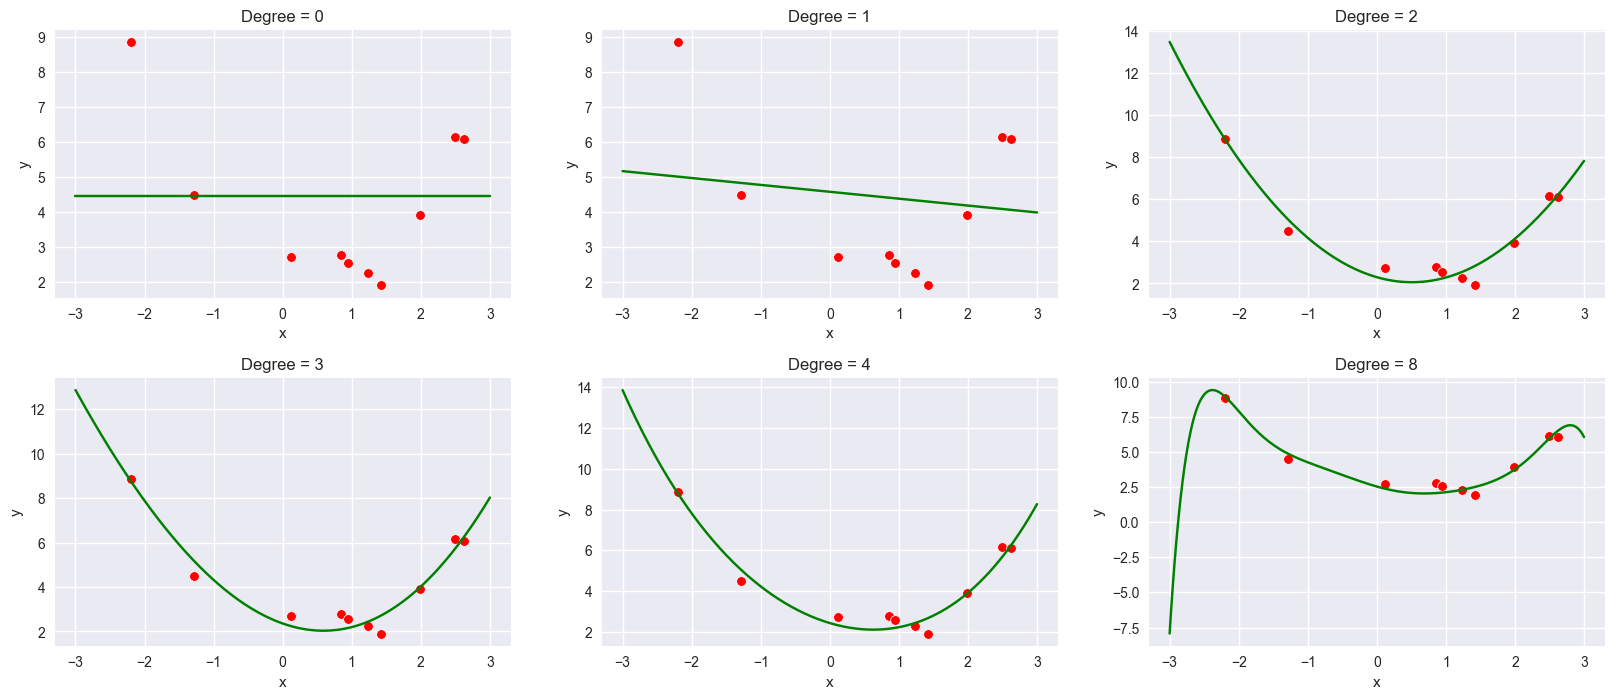

In [47]:
fig = plt.figure(figsize=(20, 8))
fig.subplots_adjust(wspace=.2, hspace=0.3)

X = np.linspace(start=-3, stop=3, num=256)

for i, p in enumerate([0, 1, 2, 3, 4, 8]):
    ax = fig.add_subplot(2, 3, i+1)
    list_Xp = [np.power(X, p_)[:, None] for p_ in range(p + 1)]

    Xp = np.concatenate(list_Xp, axis=-1)
    model = models[p]
    ypred = model.predict(Xp)

    Xtrain, ytrain = get_Xy(df_train, p)

    ax.plot(X, ypred, c='g')
    sns.scatterplot(x=df_train['x'], y=df_train['y'], ax=ax, c='red')
    ax.set_title(f"Degree = {p}")


## Task c

In [50]:
path_train = "E1/data/train_real.csv"
path_test = "E1/data/test_real.csv"

df_train, df_test = pd.read_csv(path_train), pd.read_csv(path_test)

In [51]:
df_train.head()

,station,Present_Tmax,Present_Tmin,LDAPS_RHmin,LDAPS_RHmax,LDAPS_Tmax_lapse,LDAPS_Tmin_lapse,LDAPS_WS,LDAPS_LH,LDAPS_CC1,...,LDAPS_PPT1,LDAPS_PPT2,LDAPS_PPT3,LDAPS_PPT4,lat,lon,DEM,Slope,Solar.radiation,Next_Tmax
0,18,35.7,26.0,84.447960,92.308334,26.104369,24.170859,10.891081,88.175083,0.804608,...,1.558013,1.705516,1.778125,2.28107,37.4832,127.024,56.4448,1.2313,5771.630371,28.0
1,9,30.1,21.8,70.757713,97.710205,25.931924,22.091475,3.419272,30.018019,0.338613,...,0.000000,0.001118,0.000000,0.00000,37.4967,126.826,50.9312,0.4125,5109.809570,26.6
2,19,35.2,25.4,49.067596,75.480835,34.681696,27.159026,5.989162,59.334159,0.277531,...,0.068292,0.009718,0.000000,0.00000,37.5776,126.938,75.0924,1.7678,5330.692383,35.7
3,2,33.3,24.3,60.961544,85.602119,32.305803,27.014510,4.921388,82.743785,0.193430,...,0.000000,0.000000,2.308612,0.00521,37.6046,127.032,44.7624,0.5141,5162.595703,34.4
4,9,26.9,20.7,38.462933,76.459633,28.019327,16.918262,7.882513,135.397200,0.000000,...,0.000000,0.000000,0.000000,0.00000,37.4967,126.826,50.9312,0.4125,4588.736816,28.4


In [112]:
df_train.columns

Index(['station', 'Present_Tmax', 'Present_Tmin', 'LDAPS_RHmin', 'LDAPS_RHmax',
       'LDAPS_Tmax_lapse', 'LDAPS_Tmin_lapse', 'LDAPS_WS', 'LDAPS_LH',
       'LDAPS_CC1', 'LDAPS_CC2', 'LDAPS_CC3', 'LDAPS_CC4', 'LDAPS_PPT1',
       'LDAPS_PPT2', 'LDAPS_PPT3', 'LDAPS_PPT4', 'lat', 'lon', 'DEM', 'Slope',
       'Solar.radiation', 'Next_Tmax'],
      dtype='object')

In [113]:
# cols = ['Present_Tmax', 'Present_Tmin', 'LDAPS_Tmax_lapse', 'LDAPS_Tmin_lapse']
cols = ['station', 'Present_Tmax', 'Present_Tmin', 'LDAPS_RHmin', 'LDAPS_RHmax',
       'LDAPS_Tmax_lapse', 'LDAPS_Tmin_lapse', 'LDAPS_WS', 'LDAPS_LH',
       'LDAPS_CC1', 'LDAPS_CC2', 'LDAPS_CC3', 'LDAPS_CC4', 'LDAPS_PPT1',
       'LDAPS_PPT2', 'LDAPS_PPT3', 'LDAPS_PPT4', 'lat', 'lon', 'DEM', 'Slope',
       'Solar.radiation']
trg = 'Next_Tmax'
def get_Xy(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
    X, y = df[cols], df[trg]

    return X, y

In [114]:
Xtrain, ytrain = get_Xy(df_train)
Xtest, ytest = get_Xy(df_test)

In [115]:
def dummy_predict(X: pd.DataFrame):
    return X.mean(axis=1)

In [116]:
ols = linear_model.LinearRegression()
rf = RandomForestRegressor()
boost = GradientBoostingRegressor()
svr = SVR()

In [117]:
rf.fit(Xtrain, ytrain)
svr.fit(Xtrain, ytrain)
boost.fit(Xtrain, ytrain)
ols.fit(Xtrain, ytrain)

LinearRegression()

In [118]:
models = ["Dummy", "OLS", "RF", "SVR", "GradientBoosting"]

In [119]:
mse_train = [
    mean_squared_error(ytrain, dummy_predict(Xtrain)),
    mean_squared_error(ytrain, ols.predict(Xtrain)),
    mean_squared_error(ytrain, rf.predict(Xtrain)),
    mean_squared_error(ytrain, svr.predict(Xtrain)),
    mean_squared_error(ytrain, boost.predict(Xtrain))
]

In [120]:
mse_test = [
    mean_squared_error(ytest, dummy_predict(Xtest)),
    mean_squared_error(ytest, ols.predict(Xtest)),
    mean_squared_error(ytest, rf.predict(Xtest)),
    mean_squared_error(ytest, svr.predict(Xtest)),
    mean_squared_error(ytest, boost.predict(Xtest))
]

In [121]:
df_train

,station,Present_Tmax,Present_Tmin,LDAPS_RHmin,LDAPS_RHmax,LDAPS_Tmax_lapse,LDAPS_Tmin_lapse,LDAPS_WS,LDAPS_LH,LDAPS_CC1,...,LDAPS_PPT1,LDAPS_PPT2,LDAPS_PPT3,LDAPS_PPT4,lat,lon,DEM,Slope,Solar.radiation,Next_Tmax
0,18,35.7,26.0,84.447960,92.308334,26.104369,24.170859,10.891081,88.175083,0.804608,...,1.558013,1.705516,1.778125,2.281070,37.4832,127.024,56.4448,1.2313,5771.630371,28.0
1,9,30.1,21.8,70.757713,97.710205,25.931924,22.091475,3.419272,30.018019,0.338613,...,0.000000,0.001118,0.000000,0.000000,37.4967,126.826,50.9312,0.4125,5109.809570,26.6
2,19,35.2,25.4,49.067596,75.480835,34.681696,27.159026,5.989162,59.334159,0.277531,...,0.068292,0.009718,0.000000,0.000000,37.5776,126.938,75.0924,1.7678,5330.692383,35.7
3,2,33.3,24.3,60.961544,85.602119,32.305803,27.014510,4.921388,82.743785,0.193430,...,0.000000,0.000000,2.308612,0.005210,37.6046,127.032,44.7624,0.5141,5162.595703,34.4
4,9,26.9,20.7,38.462933,76.459633,28.019327,16.918262,7.882513,135.397200,0.000000,...,0.000000,0.000000,0.000000,0.000000,37.4967,126.826,50.9312,0.4125,4588.736816,28.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,13,31.9,24.4,50.421280,71.853981,28.022607,23.679028,6.308154,26.967077,0.401045,...,0.000000,0.000000,0.000000,0.064672,37.5776,127.083,59.8324,2.6865,5715.945801,29.7
496,3,31.6,23.3,48.690479,83.973587,30.091292,24.565633,6.138224,20.573050,0.209344,...,0.000000,0.000000,0.000000,0.000000,37.5776,127.058,33.3068,0.2661,5863.555664,31.1
497,6,33.4,26.9,42.165108,84.755188,33.529817,26.514413,7.100323,72.901801,0.390823,...,0.000000,0.000000,0.000000,0.000000,37.5102,127.042,54.6384,0.1457,5379.994141,33.6
498,13,31.9,25.7,49.559288,85.119171,31.177333,26.533751,5.828576,31.421102,0.425168,...,0.000000,0.000000,0.000000,0.000000,37.5776,127.083,59.8324,2.6865,5601.636719,32.3


In [122]:
ols = linear_model.LinearRegression()
rf = RandomForestRegressor()
boost = GradientBoostingRegressor()
svr = SVR()

mse_cv_dummy = []
mse_cv_ols = []
mse_cv_rf = []
mse_cv_svr = []
mse_cv_boost = []

for idx_train, idx_val in KFold(n_splits=10).split(df_train):
    Xtrain, ytrain = get_Xy(df_train.iloc[idx_train])
    Xval, yval = get_Xy(df_train.iloc[idx_val])

    rf.fit(Xtrain, ytrain)
    svr.fit(Xtrain, ytrain)
    boost.fit(Xtrain, ytrain)
    ols.fit(Xtrain, ytrain)

    mse_cv_dummy.append(mean_squared_error(yval, dummy_predict(Xval)))
    mse_cv_ols.append(mean_squared_error(yval, ols.predict(Xval)))
    mse_cv_rf.append(mean_squared_error(yval, rf.predict(Xval)))
    mse_cv_svr.append(mean_squared_error(yval, svr.predict(Xval)))
    mse_cv_boost.append(mean_squared_error(yval, boost.predict(Xval)))

In [123]:
cv = [
    sum(mse_cv_dummy) / len(mse_cv_dummy),
    sum(mse_cv_ols) / len(mse_cv_ols),
    sum(mse_cv_rf) / len(mse_cv_rf),
    sum(mse_cv_svr) / len(mse_cv_svr),
    sum(mse_cv_boost) / len(mse_cv_boost)
]

In [124]:
df_result = pd.DataFrame({
    'Regressor': models,
    'Train': mse_train,
    'Test': mse_test,
    'CV': cv
})

In [125]:
df_result

,Regressor,Train,Test,CV
0,Dummy,57030.438971,57340.141602,57030.438971
1,OLS,1.975066,2.391045,2.198489
2,RF,0.280158,2.355351,1.954436
3,SVR,9.008714,10.904522,9.115880
4,GradientBoosting,0.476695,2.213593,1.905727
